# Bloque 4 — Diseño y construcción de pipelines ETL/ELT

**Módulo:** Extracción, Transformación y Carga de Datos desde Fuentes Múltiples (5104)
**Unidad Didáctica:** UD1 — Tipología y características de las fuentes de datos
**Duración estimada:** ~6 horas
**Curso académico:** 2026-2027

---

### Contenidos de este bloque

| Epígrafe | Contenido |
|----------|-----------|
| **4.1** | ETL vs ELT: arquitecturas, diferencias y cuándo usar cada una |
| **4.2** | Construcción de pipelines ETL con Python puro |
| **4.3** | Transformaciones: limpieza, normalización y feature engineering |
| **4.4** | Orquestación de pipelines: Airflow y alternativas |
| **4.5** | Calidad de datos y monitoreo en producción |
| **4.6** | Pipeline completo: de fuentes múltiples a dataset ML-ready |

### Criterios de evaluación asociados
> **(CE i)** Se han diseñado y construido pipelines de extracción, transformación y carga de datos
> adaptados a distintas fuentes y formatos.
> **(CE j)** Se han aplicado técnicas de validación y control de calidad de datos dentro del pipeline.

---


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import json
import time
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Librerias cargadas correctamente.")


---
## 4.1 ETL vs ELT: arquitecturas y cuándo usar cada una

### ETL — Extract, Transform, Load

El modelo clásico: los datos se extraen de las fuentes, se transforman en un servidor
intermedio (a menudo llamado *staging area*) y finalmente se cargan en el destino ya limpios.

```
[Fuente 1]  ──┐
[Fuente 2]  ──┤──> [Staging / Motor ETL] ──> [Transformacion] ──> [Data Warehouse]
[Fuente N]  ──┘
```

**Ventajas:**
- El destino recibe datos ya limpios y listos para consultar.
- Protege el destino de datos sucios.
- Ideal cuando el destino tiene capacidad de cómputo limitada.

### ELT — Extract, Load, Transform

El modelo moderno: los datos se cargan **en bruto** en el destino (normalmente un data lake o
un data warehouse en la nube) y la transformación se realiza **dentro** del propio destino,
aprovechando su potencia de cómputo.

```
[Fuente 1]  ──┐
[Fuente 2]  ──┤──> [Data Lake / DW en nube] ──> [Transformacion in-situ] ──> [Tablas analíticas]
[Fuente N]  ──┘
```

**Ventajas:**
- El dato en bruto siempre queda disponible (trazabilidad).
- Los data warehouses modernos (BigQuery, Snowflake, Redshift) son muy potentes para transformar.
- Fácil re-transformar sin re-extraer.

### ¿Cuándo usar cada uno?

| Criterio | ETL | ELT |
|----------|-----|-----|
| Datos sensibles (GDPR) | Mejor: anonimizar antes de cargar | Con cuidado |
| Volumen muy grande | Puede saturar el staging | Ideal |
| Destino legacy (capacidad limitada) | Ideal | No recomendado |
| Agilidad / re-transformar | Lento (re-extraer) | Rápido |
| Herramientas | Informatica, Talend, dbt+Airflow | dbt, Spark SQL, BigQuery |

El diagrama siguiente compara ambas arquitecturas.


![ETL frente a ELT](imagenes/b4_etl_elt.png)

---
## 4.2 Construcción de pipelines ETL con Python puro

Un pipeline ETL bien diseñado sigue el principio de **separación de responsabilidades**:
cada etapa hace una sola cosa y las etapas se encadenan limpiamente.

### Patrón de diseño: funciones encadenables

```python
def extraer(ruta: str) -> pd.DataFrame:       ...
def transformar(df: pd.DataFrame) -> pd.DataFrame: ...
def cargar(df: pd.DataFrame, destino: str):   ...

# Pipeline
df_raw       = extraer('fuente.csv')
df_limpio    = transformar(df_raw)
cargar(df_limpio, 'destino.db')
```

### Diseño robusto: contexto de ejecución

Un pipeline de producción registra metadatos de cada ejecución:
cuántos registros entraron, cuántos salieron, cuánto tardó, qué errores hubo.

Vamos a construir un pipeline completo con tres fuentes heterogéneas.


### El problema: datos industriales dispersos en tres sistemas

Imaginemos una planta de fabricación que monitoriza cuatro sensores físicos (S01–S04).
Los datos relevantes para entrenar un modelo de **detección de anomalías** están repartidos
en tres sistemas distintos, con formatos distintos y calidad distinta:

---

**Fuente 1 — CSV de lecturas de sensores**

Cada fila es una lectura tomada cada 10 minutos por uno de los cuatro sensores.
Contiene temperatura, presión y si el sensor estaba activo en ese momento.
Este fichero tiene problemas de calidad habituales en sistemas SCADA:

- Algunos valores de temperatura son `NaN` (fallo de comunicación con el sensor).
- Unos pocos valores son `999.0`, un código de error del sensor que debe tratarse como nulo.
- La columna `activo` puede valer `True`, `False` o `None`.

**Transformaciones necesarias:** convertir tipos, eliminar outliers físicamente imposibles
(temperatura > 200 °C), imputar nulos con la mediana del propio sensor, extraer
características temporales (hora, día de la semana, turno laboral) y normalizar.

---

**Fuente 2 — SQLite de averías**

Cada fila registra una avería ocurrida en un sensor: fecha, sensor afectado y gravedad
(`baja`, `media`, `alta`). Esta tabla la mantiene el equipo de mantenimiento.

**Transformaciones necesarias:** convertir la fecha a tipo `datetime`, codificar la gravedad
como número ordinal (1/2/3) y agregar por sensor para obtener el **número total de averías**
y la **gravedad máxima histórica** de cada sensor.

---

**Fuente 3 — JSON de metadatos de sensores**

Un fichero JSON con información estática de cada sensor: en qué planta está instalado
(A o B), el fabricante (Siemens, ABB, Honeywell) y la fecha de instalación.

**Transformaciones necesarias:** pivotar el JSON a formato tabular (un sensor por fila)
y codificar las variables categóricas para que el modelo pueda usarlas.

---

### Resultado esperado

Al final del pipeline tendremos un único `DataFrame` con una fila por lectura de sensor,
que combina la señal temporal (temperatura, presión, turno), el historial de averías del
sensor y sus metadatos físicos. Este dataset estará listo para ser usado directamente
como entrada a un clasificador binario (lectura normal vs. anomalía).

| Grupo de columnas | Ejemplos |
|-------------------|---------|
| Señal temporal | `temperatura`, `presion`, `temp_norm`, `temp_media_6h`, `turno` |
| Historial de averías | `n_averias`, `max_gravedad` |
| Metadatos del sensor | `planta`, `fabricante` |
| Variable objetivo | `anomalia` (1 si temperatura > media_sensor + 2·σ) |


In [ ]:
# ── Generar tres fuentes de datos sintéticas ──────────────────────────────
np.random.seed(0)

# Fuente 1: CSV de sensores industriales
n1 = 1000
df_sensores = pd.DataFrame({
    'timestamp': pd.date_range('2024-01-01', periods=n1, freq='10min').astype(str),
    'sensor_id': np.random.choice(['S01', 'S02', 'S03', 'S04'], n1),
    'temperatura': np.round(np.random.normal(65, 12, n1), 2),
    'presion':     np.round(np.random.normal(2.5, 0.4, n1), 3),
    'activo':      np.random.choice([True, False, None], n1, p=[0.8, 0.15, 0.05]),
})
# Introducir valores faltantes y outliers a proposito
df_sensores.loc[np.random.choice(n1, 40, replace=False), 'temperatura'] = np.nan
df_sensores.loc[np.random.choice(n1, 5,  replace=False), 'temperatura'] = 999.0

RUTA_CSV = Path('sensores.csv')
df_sensores.to_csv(RUTA_CSV, index=False)

# Fuente 2: SQLite con tabla de averias
conn = sqlite3.connect('averias.db')
n2 = 200
pd.DataFrame({
    'id':        range(1, n2 + 1),
    'sensor_id': np.random.choice(['S01', 'S02', 'S03', 'S04', 'S05'], n2),
    'gravedad':  np.random.choice(['baja', 'media', 'alta'], n2, p=[0.6, 0.3, 0.1]),
    'fecha':     [(datetime(2024, 1, 1) + timedelta(days=int(d))).strftime('%Y-%m-%d')
                  for d in np.random.randint(0, 180, n2)],
}).to_sql('averias', conn, if_exists='replace', index=False)
conn.close()

# Fuente 3: JSON con metadatos de sensores
metadatos = {s: {'planta': np.random.choice(['A', 'B']),
                 'fabricante': np.random.choice(['Siemens', 'ABB', 'Honeywell']),
                 'instalado':  f'202{np.random.randint(0, 4)}-0{np.random.randint(1, 9)}-01'}
             for s in ['S01', 'S02', 'S03', 'S04']}
Path('metadatos.json').write_text(json.dumps(metadatos, indent=2))

print(f"Fuente 1 (CSV):    {len(df_sensores):,} filas  ->  {RUTA_CSV}")
print(f"Fuente 2 (SQLite): {n2} averias     ->  averias.db")
print(f"Fuente 3 (JSON):   {len(metadatos)} sensores  ->  metadatos.json")

In [ ]:
# ── Etapa EXTRACT ──────────────────────────────────────────────────────────
def extraer_csv(ruta: Path) -> pd.DataFrame:
    df = pd.read_csv(ruta)
    print(f"  [CSV]    {len(df):,} filas  |  columnas: {list(df.columns)}")
    return df

def extraer_sql(ruta_db: str, tabla: str) -> pd.DataFrame:
    conn = sqlite3.connect(ruta_db)
    df = pd.read_sql_query(f"SELECT * FROM {tabla}", conn)
    conn.close()
    print(f"  [SQLite] {len(df):,} filas  |  columnas: {list(df.columns)}")
    return df

def extraer_json(ruta: Path) -> pd.DataFrame:
    datos = json.loads(ruta.read_text())
    df = pd.DataFrame.from_dict(datos, orient='index').reset_index()
    df.rename(columns={'index': 'sensor_id'}, inplace=True)
    print(f"  [JSON]   {len(df)} filas   |  columnas: {list(df.columns)}")
    return df

print("=== EXTRACT ===")
t0 = time.perf_counter()
df_raw_csv  = extraer_csv(RUTA_CSV)
df_raw_sql  = extraer_sql('averias.db', 'averias')
df_raw_json = extraer_json(Path('metadatos.json'))
t_ext = time.perf_counter() - t0
print(f"  Tiempo extraccion: {t_ext:.3f} s")

In [ ]:
# ── Etapa TRANSFORM ────────────────────────────────────────────────────────
def transformar_sensores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Tipos de datos
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['activo'] = df['activo'].map({'True': True, 'False': False, True: True, False: False})

    # 2. Eliminar outliers de temperatura (> 200 grados es imposible)
    n_outliers = (df['temperatura'] > 200).sum()
    df.loc[df['temperatura'] > 200, 'temperatura'] = np.nan
    print(f"  Outliers eliminados: {n_outliers}")

    # 3. Imputar NaN con la mediana del sensor
    for sid in df['sensor_id'].unique():
        mask = (df['sensor_id'] == sid) & df['temperatura'].isna()
        mediana = df.loc[df['sensor_id'] == sid, 'temperatura'].median()
        df.loc[mask, 'temperatura'] = mediana

    # 4. Feature engineering
    df['hora'] = df['timestamp'].dt.hour
    df['dia_semana'] = df['timestamp'].dt.dayofweek
    df['turno'] = pd.cut(df['hora'], bins=[-1, 7, 15, 23],
                         labels=['noche', 'manana', 'tarde'])
    df['temp_norm'] = (df['temperatura'] - df['temperatura'].mean()) / df['temperatura'].std()

    # 5. Flag de anomalia: temperatura > media_sensor + 2*std_sensor
    df['temp_media_s'] = df.groupby('sensor_id')['temperatura'].transform('mean')
    df['temp_std_s']   = df.groupby('sensor_id')['temperatura'].transform('std').fillna(0)
    df['anomalia']     = (df['temperatura'] > df['temp_media_s'] + 2 * df['temp_std_s']).astype(int)
    df.drop(columns=['temp_media_s', 'temp_std_s'], inplace=True)

    print(f"  Shape final: {df.shape}")
    print(f"  Nulos restantes: {df.isnull().sum().sum()}")
    return df

def transformar_averias(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['fecha'] = pd.to_datetime(df['fecha'])
    df['gravedad_num'] = df['gravedad'].map({'baja': 1, 'media': 2, 'alta': 3})
    return df

print("=== TRANSFORM ===")
t0 = time.perf_counter()
df_sensores_t = transformar_sensores(df_raw_csv)
df_averias_t  = transformar_averias(df_raw_sql)
t_tr = time.perf_counter() - t0
print(f"  Tiempo transformacion: {t_tr:.3f} s")
print()
print("Muestra de df_sensores_t:")
print(df_sensores_t[['timestamp', 'sensor_id', 'temperatura', 'temp_norm', 'turno']].head(4).to_string())


In [ ]:
# ── Join de fuentes y etapa LOAD ───────────────────────────────────────────
def integrar_fuentes(df_sens, df_aver, df_meta) -> pd.DataFrame:
    # Agregar averias por sensor: total y max gravedad
    aver_agg = df_aver.groupby('sensor_id').agg(
        n_averias=('id', 'count'),
        max_gravedad=('gravedad_num', 'max')
    ).reset_index()

    # JOIN sensores + averias
    df = df_sens.merge(aver_agg, on='sensor_id', how='left')

    # JOIN con metadatos
    df = df.merge(df_meta, on='sensor_id', how='left')

    # Rellenar NaN de averias (sensores sin averias)
    df['n_averias']   = df['n_averias'].fillna(0).astype(int)
    df['max_gravedad'] = df['max_gravedad'].fillna(0).astype(int)

    return df

def cargar_sqlite(df: pd.DataFrame, ruta_db: str, tabla: str):
    conn = sqlite3.connect(ruta_db)
    df.to_sql(tabla, conn, if_exists='replace', index=False)
    conn.close()

print("=== LOAD ===")
t0 = time.perf_counter()
df_final = integrar_fuentes(df_sensores_t, df_averias_t, df_raw_json)
cargar_sqlite(df_final, 'dataset_ml.db', 'features_ml')
t_load = time.perf_counter() - t0

print(f"  Shape dataset final: {df_final.shape}")
print(f"  Columnas: {list(df_final.columns)}")
print(f"  Tiempo carga: {t_load:.3f} s")
print()
print(f"  Tiempo total del pipeline: {t_ext + t_tr + t_load:.3f} s")

---
## 4.3 Transformaciones: limpieza, normalización y feature engineering

Las transformaciones son la parte más crítica del pipeline: de su calidad depende directamente
la calidad del modelo ML. Podemos agruparlas en tres categorías:

| Categoría | Ejemplos |
|-----------|---------|
| **Limpieza** | Eliminar duplicados, imputar nulos, corregir tipos, filtrar outliers |
| **Normalización** | Min-Max, Z-score, logarítmica; encodings de categorías |
| **Feature engineering** | Ventanas temporales, interacciones, extracción de fecha/hora |

### Regla de oro

> **Transformar siempre dentro del pipeline, nunca en el origen.**
> Las transformaciones deben ser reproducibles, versionadas y revertibles.

Vamos a aplicar un conjunto completo de transformaciones sobre el dataset anterior.


![Categorías de transformaciones en un pipeline ETL](imagenes/b4_transformaciones.png)

In [ ]:
# ── Transformaciones avanzadas sobre el dataset ───────────────────────────
df = df_final.copy()

# 1. Codificacion de categorias
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

le = LabelEncoder()
df['sensor_id_enc'] = le.fit_transform(df['sensor_id'])
df['turno_enc']     = le.fit_transform(df['turno'].astype(str))
df['planta_enc']    = le.fit_transform(df['planta'].astype(str))

# 2. Normalizacion Min-Max de variables numericas continuas
scaler = MinMaxScaler()
cols_num = ['temperatura', 'presion', 'temp_norm']
df[['temp_mm', 'pres_mm', 'tnorm_mm']] = scaler.fit_transform(df[cols_num].fillna(0))

# 3. Feature engineering temporal: ventana rodante (rolling)
df = df.sort_values(['sensor_id', 'timestamp']).reset_index(drop=True)
df['temp_media_6h'] = (df.groupby('sensor_id')['temperatura']
                         .transform(lambda x: x.rolling(6, min_periods=1).mean()))
df['temp_std_6h']   = (df.groupby('sensor_id')['temperatura']
                         .transform(lambda x: x.rolling(6, min_periods=1).std().fillna(0)))

# 4. Flag de anomalia: temperatura > media + 2*std del sensor
stats = df.groupby('sensor_id')['temperatura'].agg(['mean', 'std']).reset_index()
df = df.merge(stats, on='sensor_id', how='left', suffixes=('', '_global'))
df['anomalia'] = (df['temperatura'] > df['mean'] + 2 * df['std']).astype(int)

print("Columnas finales del dataset ML:")
cols_show = ['timestamp', 'sensor_id', 'temperatura', 'temp_mm', 'temp_media_6h',
             'turno_enc', 'n_averias', 'anomalia']
print(df[cols_show].head(6).to_string())
print(f"\nShape: {df.shape}  |  Anomalias detectadas: {df['anomalia'].sum()}")


In [ ]:
# Visualizacion de la distribucion antes y despues de normalizar
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax1, ax2, ax3 = axes

ax1.hist(df_final['temperatura'].dropna(), bins=40, color='#e74c3c',
         edgecolor='white', linewidth=0.6)
ax1.set_title('Temperatura original')
ax1.set_xlabel('Grados')
ax1.set_ylabel('Frecuencia')
ax1.grid(True, alpha=0.3)

ax2.hist(df['temp_mm'].dropna(), bins=40, color='#2980b9',
         edgecolor='white', linewidth=0.6)
ax2.set_title('Temperatura Min-Max normalizada')
ax2.set_xlabel('Valor [0, 1]')
ax2.grid(True, alpha=0.3)

turno_counts = df['turno'].value_counts()
ax3.bar(turno_counts.index, turno_counts.values,
        color=['#16a085', '#e67e22', '#8e44ad'], edgecolor='white', linewidth=0.8)
ax3.set_title('Registros por turno')
ax3.set_xlabel('Turno')
ax3.set_ylabel('Conteo')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


![Arquitectura de orquestación con Apache Airflow](imagenes/b4_airflow.png)

### Cómo funciona Apache Airflow

Apache Airflow es una plataforma de orquestación de flujos de trabajo que permite
definir, planificar y monitorear pipelines complejos como código Python. Su arquitectura
distribuida se compone de los siguientes componentes:

**Webserver**
Interfaz web (Flask) que permite a los usuarios visualizar los DAGs, consultar el
historial de ejecuciones, ver los logs de cada tarea y lanzar ejecuciones manuales.
Es el único punto de contacto del usuario con el sistema.

**Scheduler**
El componente central. Analiza continuamente los DAGs del directorio configurado,
determina qué tareas están listas para ejecutarse (respetando las dependencias entre
ellas y el horario definido) y las encola en el broker de mensajería.

**Executor / Worker nodes**
Los workers recogen tareas de la cola y las ejecutan. Airflow soporta varios tipos de
executor: `LocalExecutor` (un solo servidor, múltiples procesos), `CeleryExecutor`
(varios workers en máquinas distintas, con RabbitMQ o Redis como broker) y
`KubernetesExecutor` (cada tarea se ejecuta en un pod de Kubernetes independiente).

**Metadata Database (MySQL / PostgreSQL)**
Base de datos relacional que actúa como fuente de verdad del sistema: almacena el
estado de cada DAG y cada tarea (pendiente, en ejecución, completada, fallida), los
logs, las conexiones a servicios externos y las variables de configuración.

**DAGs Directory**
Carpeta compartida (o repositorio Git sincronizado) donde se guardan los ficheros Python
que definen los DAGs. El Scheduler la escanea periódicamente para detectar DAGs nuevos
o modificados.

El diagrama siguiente muestra cómo interactúan estos componentes en una instalación
con CeleryExecutor (el modo distribuido más habitual en producción):

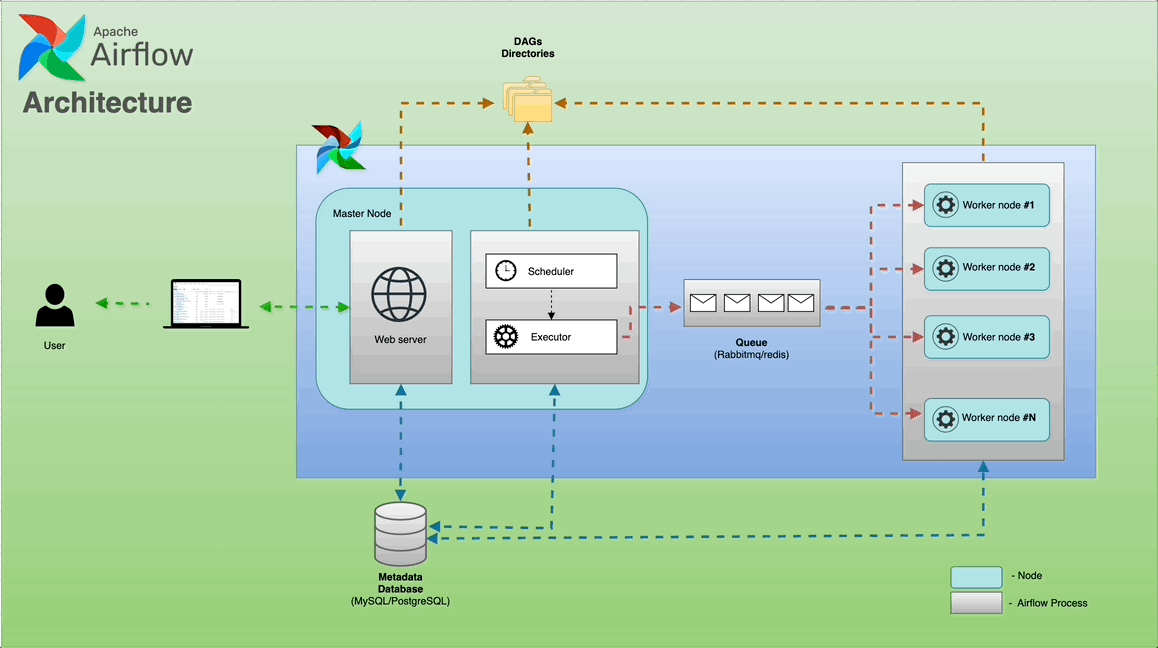

> **Para saber más:** puedes aprender cómo funciona Apache Airflow en este vídeo:
> [https://www.youtube.com/watch?v=PJzIzytxJ2M](https://www.youtube.com/watch?v=PJzIzytxJ2M)


---
## 4.5 Calidad de datos y monitoreo en producción

Un pipeline ETL de producción no puede confiar ciegamente en los datos de entrada.
Necesita **validaciones** que detecten problemas antes de que lleguen al modelo:

### Tipos de validaciones

| Tipo | Qué verifica | Ejemplo |
|------|-------------|---------|
| **Esquema** | Columnas y tipos correctos | `temperatura` debe ser float |
| **Rango** | Valores dentro de límites | `0 <= presion <= 10` |
| **Nulos** | Porcentaje aceptable de nulos | máx 5% en columna clave |
| **Cardinalidad** | Categorías esperadas | `sensor_id` solo S01–S04 |
| **Freshness** | Datos recientes | timestamp máx < 24 h |
| **Unicidad** | Sin duplicados en clave | `(timestamp, sensor_id)` único |

### Herramientas dedicadas

- **Great Expectations**: validaciones declarativas con informes HTML.
- **Pandera**: esquemas de pandas con tipos y restricciones.
- **dbt tests**: validaciones SQL integradas en el pipeline ELT.

Vamos a implementar un validador ligero basado en pandas.


![Pipeline con validación de calidad de datos](imagenes/b4_calidad.png)

In [ ]:
# Validador ligero de calidad de datos
class ValidadorDatos:
    def __init__(self, nombre):
        self.nombre   = nombre
        self.checks   = []
        self.n_ok     = 0
        self.n_fail   = 0

    def check(self, descripcion, condicion, detalle=''):
        resultado = bool(condicion)
        estado    = 'OK  ' if resultado else 'FAIL'
        self.checks.append({'descripcion': descripcion, 'ok': resultado, 'detalle': detalle})
        if resultado:
            self.n_ok += 1
        else:
            self.n_fail += 1
        print(f"  [{estado}] {descripcion}  {detalle}")

    def resumen(self):
        total = self.n_ok + self.n_fail
        print(f"  ---")
        print(f"  Resultado: {self.n_ok}/{total} checks OK  "
              f"({'PASS' if self.n_fail == 0 else 'FAIL — revisar pipeline'})")
        return self.n_fail == 0

# Validar el dataset transformado
v = ValidadorDatos('dataset_sensores')
print(f"=== Validacion de calidad: {v.nombre} ===")

cols_requeridas = ['timestamp', 'sensor_id', 'temperatura', 'presion', 'turno']
v.check("Columnas requeridas presentes",
        all(c in df.columns for c in cols_requeridas))

v.check("Sin nulos en sensor_id",
        df['sensor_id'].isna().sum() == 0,
        f"({df['sensor_id'].isna().sum()} nulos)")

pct_nulos_temp = df['temperatura'].isna().mean() * 100
v.check("Nulos temperatura < 5%",
        pct_nulos_temp < 5.0,
        f"({pct_nulos_temp:.1f}%)")

v.check("Rango temperatura [10, 150]",
        df['temperatura'].dropna().between(10, 150).all(),
        f"(min={df['temperatura'].min():.1f}, max={df['temperatura'].max():.1f})")

sensores_validos = {'S01', 'S02', 'S03', 'S04'}
sensores_en_datos = set(df['sensor_id'].unique())
v.check("Sensores conocidos",
        sensores_en_datos.issubset(sensores_validos),
        f"({sensores_en_datos})")

n_dup = df.duplicated(subset=['timestamp', 'sensor_id']).sum()
v.check("Sin duplicados (timestamp, sensor_id)",
        n_dup == 0,
        f"({n_dup} duplicados)")

ts_max = pd.to_datetime(df['timestamp']).max()
dias_diff = (datetime.now() - ts_max.to_pydatetime()).days
v.check("Datos recientes (< 365 dias)",
        dias_diff < 365,
        f"({dias_diff} dias desde el ultimo registro)")

ok = v.resumen()
print(f"{'Pipeline VALIDADO' if ok else 'Pipeline CON ALERTAS'}")


---
## 4.6 Pipeline completo: de fuentes múltiples a dataset ML-ready

Vamos a encadenar todo lo visto en un pipeline reproducible que:
1. Extrae datos de tres fuentes heterogéneas
2. Valida la calidad en la entrada
3. Transforma y enriquece
4. Valida la calidad en la salida
5. Carga el dataset final en SQLite y Parquet
6. Genera un informe de ejecución

Este patrón es el que se usa en producción, escalado con Airflow o Prefect.


![Pipeline completo: de fuentes múltiples a un dataset listo para ML](imagenes/b4_pipeline_completo.png)

In [ ]:
# Pipeline completo integrado
def pipeline_completo(cfg: dict) -> dict:
    informe = {
        'inicio':       datetime.now().isoformat(),
        'n_extraidos':  0,
        'n_finales':    0,
        'checks_ok':    0,
        'checks_total': 0,
        'errores':      [],
        'duracion_s':   0.0,
    }
    t_total = time.perf_counter()

    # ── EXTRACT ──────────────────────────────────────────────────────────
    try:
        df_s = extraer_csv(Path(cfg['csv']))
        df_a = extraer_sql(cfg['db'], 'averias')
        df_m = extraer_json(Path(cfg['json']))
        informe['n_extraidos'] = len(df_s)
    except Exception as e:
        informe['errores'].append(f"EXTRACT: {e}")
        return informe

    # ── VALIDACION ENTRADA ────────────────────────────────────────────────
    v_in = ValidadorDatos('entrada')
    v_in.check("CSV no vacio", len(df_s) > 0, f"({len(df_s)} filas)")
    v_in.check("Columna temperatura existe", 'temperatura' in df_s.columns)
    v_in.check("Columna sensor_id existe",  'sensor_id' in df_s.columns)
    informe['checks_ok']    += v_in.n_ok
    informe['checks_total'] += v_in.n_ok + v_in.n_fail

    # ── TRANSFORM ────────────────────────────────────────────────────────
    df_s_t = transformar_sensores(df_s)
    df_a_t = transformar_averias(df_a)
    df_out = integrar_fuentes(df_s_t, df_a_t, df_m)

    # Añadir hash de reproducibilidad por fila
    df_out['row_hash'] = df_out.apply(
        lambda r: hashlib.md5(str(r.to_dict()).encode()).hexdigest()[:10], axis=1)

    informe['n_finales'] = len(df_out)

    # ── VALIDACION SALIDA ─────────────────────────────────────────────────
    v_out = ValidadorDatos('salida')
    v_out.check("Sin perdida de filas",
                len(df_out) == informe['n_extraidos'],
                f"({informe['n_extraidos']} -> {len(df_out)})")
    v_out.check("Columna row_hash presente", 'row_hash' in df_out.columns)
    v_out.check("Sin nulos en sensor_id", df_out['sensor_id'].isna().sum() == 0)
    informe['checks_ok']    += v_out.n_ok
    informe['checks_total'] += v_out.n_ok + v_out.n_fail

    # ── LOAD ──────────────────────────────────────────────────────────────
    # SQLite
    cargar_sqlite(df_out, cfg['destino_db'], 'features_ml')
    # Parquet
    df_out.to_parquet(cfg['destino_parquet'], index=False)

    informe['duracion_s'] = round(time.perf_counter() - t_total, 3)
    informe['fin']        = datetime.now().isoformat()
    return informe

# Ejecutar el pipeline completo
print("=== Pipeline completo ===")
cfg = {
    'csv':             'sensores.csv',
    'db':              'averias.db',
    'json':            'metadatos.json',
    'destino_db':      'dataset_final.db',
    'destino_parquet': 'dataset_final.parquet',
}

informe = pipeline_completo(cfg)

print()
print("=== INFORME DE EJECUCION ===")
for k, v in informe.items():
    print(f"  {k:<20s}: {v}")

tam_pq = Path(cfg['destino_parquet']).stat().st_size / 1e3
tam_db = Path(cfg['destino_db']).stat().st_size / 1e3
print(f"  {'tamano_parquet':<20s}: {tam_pq:.1f} KB")
print(f"  {'tamano_sqlite':<20s}: {tam_db:.1f} KB")

In [ ]:
# Verificacion del dataset final guardado en Parquet
df_verificacion = pd.read_parquet('dataset_final.parquet')
print(f"Dataset ML-ready cargado desde Parquet:")
print(f"  Shape:    {df_verificacion.shape}")
print(f"  Columnas: {list(df_verificacion.columns)}")
print()
print("Estadisticas descriptivas (numericas):")
print(df_verificacion[['temperatura', 'presion', 'temp_norm',
                        'n_averias', 'anomalia']].describe().round(3).to_string())

---
## Resumen del bloque

| Concepto | Clave |
|----------|-------|
| **ETL** | Transforma antes de cargar; protege el destino |
| **ELT** | Carga en bruto, transforma in-situ; más ágil con DW modernos |
| **Separación de etapas** | Extract / Transform / Load como funciones independientes |
| **Validación de calidad** | Antes y después de cada transformación |
| **Orquestación** | Airflow / Prefect / cron para planificar y monitorear |
| **Reproducibilidad** | Hash de filas, versionado de transformaciones |

---
_Fin del Bloque 4 y de la UD1.
La UD2 cubre la extracción desde ficheros planos, JSON, XML y formatos optimizados para ML._